# Preparación del raster para clasificación

Este notebook documenta la preparación del raster multibanda que será usado en el flujo de clasificación de coberturas.

El proceso incluye:

- revisión de raster recortados por humedal;
- selección del raster de trabajo;
- visualización RGB y visualización de bandas;
- definición de nombres reales de variables;
- análisis de correlación Pearson y Spearman;
- selección de variables por correlación;
- generación de un raster reducido;
- preprocesamiento del raster reducido para uso posterior en modelos de clasificación.

Las salidas generadas en esta etapa serán usadas en la preparación de muestras, entrenamiento, evaluación e inferencia espacial.


In [1]:
from pathlib import Path
import sys

import pandas as pd

In [2]:
BASE_DIR = Path.cwd()

while not (BASE_DIR / "src").exists() and BASE_DIR != BASE_DIR.parent:
    BASE_DIR = BASE_DIR.parent

sys.path.append(str(BASE_DIR))

print("BASE_DIR detectado:")
print(BASE_DIR)

BASE_DIR detectado:
C:\Users\AVDON\JupyterLab\ATENEA\humedales_bogota_ml


## Importación de funciones auxiliares

Las funciones para visualización y preparación del raster se encuentran en:

- `src/clasificacion_coberturas/visualizacion.py`
- `src/clasificacion_coberturas/preparacion_raster.py`

Esto permite mantener el notebook como una interfaz de ejecución documentada, mientras la lógica principal queda centralizada en módulos reutilizables.


In [3]:
from src.clasificacion_coberturas.visualizacion import (
    visualizar_mosaico_rasters,
    visualizar_mosaico_bandas,
    graficar_matriz_correlacion
)

from src.clasificacion_coberturas.preparacion_raster import (
    obtener_feature_names_clasificacion,
    obtener_grupos_bandas,
    pipeline_preparacion_raster,
    preprocesar_raster
)

## Configuración de rutas

Se definen las rutas de entrada y salida para esta etapa.

El raster de entrada corresponde a uno de los recortes generados en `02_recorte_humedales.ipynb`.

Las salidas principales serán:

- raster reducido por selección de variables;
- archivo JSON con las variables seleccionadas;
- tablas de correlación y selección de variables;
- figuras de visualización y correlación.


In [4]:
# ============================================================
# CONFIGURACIÓN GENERAL
# ============================================================

year = 2018

carpeta_rasters_recortados = (
    BASE_DIR
    / "data"
    / "interim"
    / "clasificacion_coberturas"
    / f"RPR_{year}"
)

carpeta_reducidos = (
    BASE_DIR
    / "data"
    / "interim"
    / "clasificacion_coberturas"
    / "reducidos"
)

carpeta_tablas = (
    BASE_DIR
    / "outputs"
    / "tables"
    / "clasificacion_coberturas"
)

carpeta_figuras = (
    BASE_DIR
    / "outputs"
    / "figures"
    / "clasificacion_coberturas"
)

print("Carpeta de raster recortados:")
print(carpeta_rasters_recortados)

print("\nCarpeta de raster reducidos:")
print(carpeta_reducidos)

print("\nCarpeta de tablas:")
print(carpeta_tablas)

print("\nCarpeta de figuras:")
print(carpeta_figuras)

Carpeta de raster recortados:
C:\Users\AVDON\JupyterLab\ATENEA\humedales_bogota_ml\data\interim\clasificacion_coberturas\RPR_2018

Carpeta de raster reducidos:
C:\Users\AVDON\JupyterLab\ATENEA\humedales_bogota_ml\data\interim\clasificacion_coberturas\reducidos

Carpeta de tablas:
C:\Users\AVDON\JupyterLab\ATENEA\humedales_bogota_ml\outputs\tables\clasificacion_coberturas

Carpeta de figuras:
C:\Users\AVDON\JupyterLab\ATENEA\humedales_bogota_ml\outputs\figures\clasificacion_coberturas


## Selección del raster de trabajo

Se listan los raster recortados disponibles y se define el raster que será usado para el análisis de correlación y preparación del insumo del modelo.

El nombre del archivo puede modificarse según el humedal o área de interés que se desee procesar.


In [5]:
rutas_rasters = sorted(carpeta_rasters_recortados.glob("*_clip.tif"))

print("Número de raster recortados encontrados:")
print(len(rutas_rasters))

for ruta in rutas_rasters:
    print(ruta.name)

Número de raster recortados encontrados:
22
pdem_entre_nubes_cerro_juan_rey_clip.tif
pdem_entre_nubes_cuchilla_el_gavilan_clip.tif
pdem_entre_nubes_cuchilla_guacamayas_clip.tif
pdem_mirador_de_los_nevados_clip.tif
pdem_serrania_del_zuque_clip.tif
pdem_soratama_clip.tif
rdh_chiguasuque_la_isla_clip.tif
rdh_complejo_de_humedales_el_tunjo_clip.tif
rdh_de_capellania_o_la_cofradia_clip.tif
rdh_de_cordoba_niza_clip.tif
rdh_de_jaboque_clip.tif
rdh_de_juan_amarillo_o_tibabuyes_clip.tif
rdh_de_la_conejera_clip.tif
rdh_de_la_vaca_clip.tif
rdh_de_santa_maria_del_lago_clip.tif
rdh_de_techo_clip.tif
rdh_de_tibanica_clip.tif
rdh_de_torca_y_guaymaral_clip.tif
rdh_del_burro_clip.tif
rdh_del_meandro_del_say_clip.tif
rdh_salitre_clip.tif
rdh_tingua_azul_clip.tif


In [6]:
# ============================================================
# RASTER SELECCIONADO
# ============================================================

nombre_raster_seleccionado = "pdem_entre_nubes_cuchilla_guacamayas_clip.tif"

ruta_raster = carpeta_rasters_recortados / nombre_raster_seleccionado

if not ruta_raster.exists():
    raise FileNotFoundError(f"No se encontró el raster seleccionado: {ruta_raster}")

print("Raster seleccionado:")
print(ruta_raster)

Raster seleccionado:
C:\Users\AVDON\JupyterLab\ATENEA\humedales_bogota_ml\data\interim\clasificacion_coberturas\RPR_2018\pdem_entre_nubes_cuchilla_guacamayas_clip.tif


## Visualización preliminar de raster recortados

Se genera un mosaico RGB de los raster recortados disponibles. Esta visualización permite revisar rápidamente la cobertura espacial y apariencia general de los recortes generados en la etapa anterior.


Figura guardada en:
C:\Users\AVDON\JupyterLab\ATENEA\humedales_bogota_ml\outputs\figures\clasificacion_coberturas\mosaico_rasters_recortados_2018.png


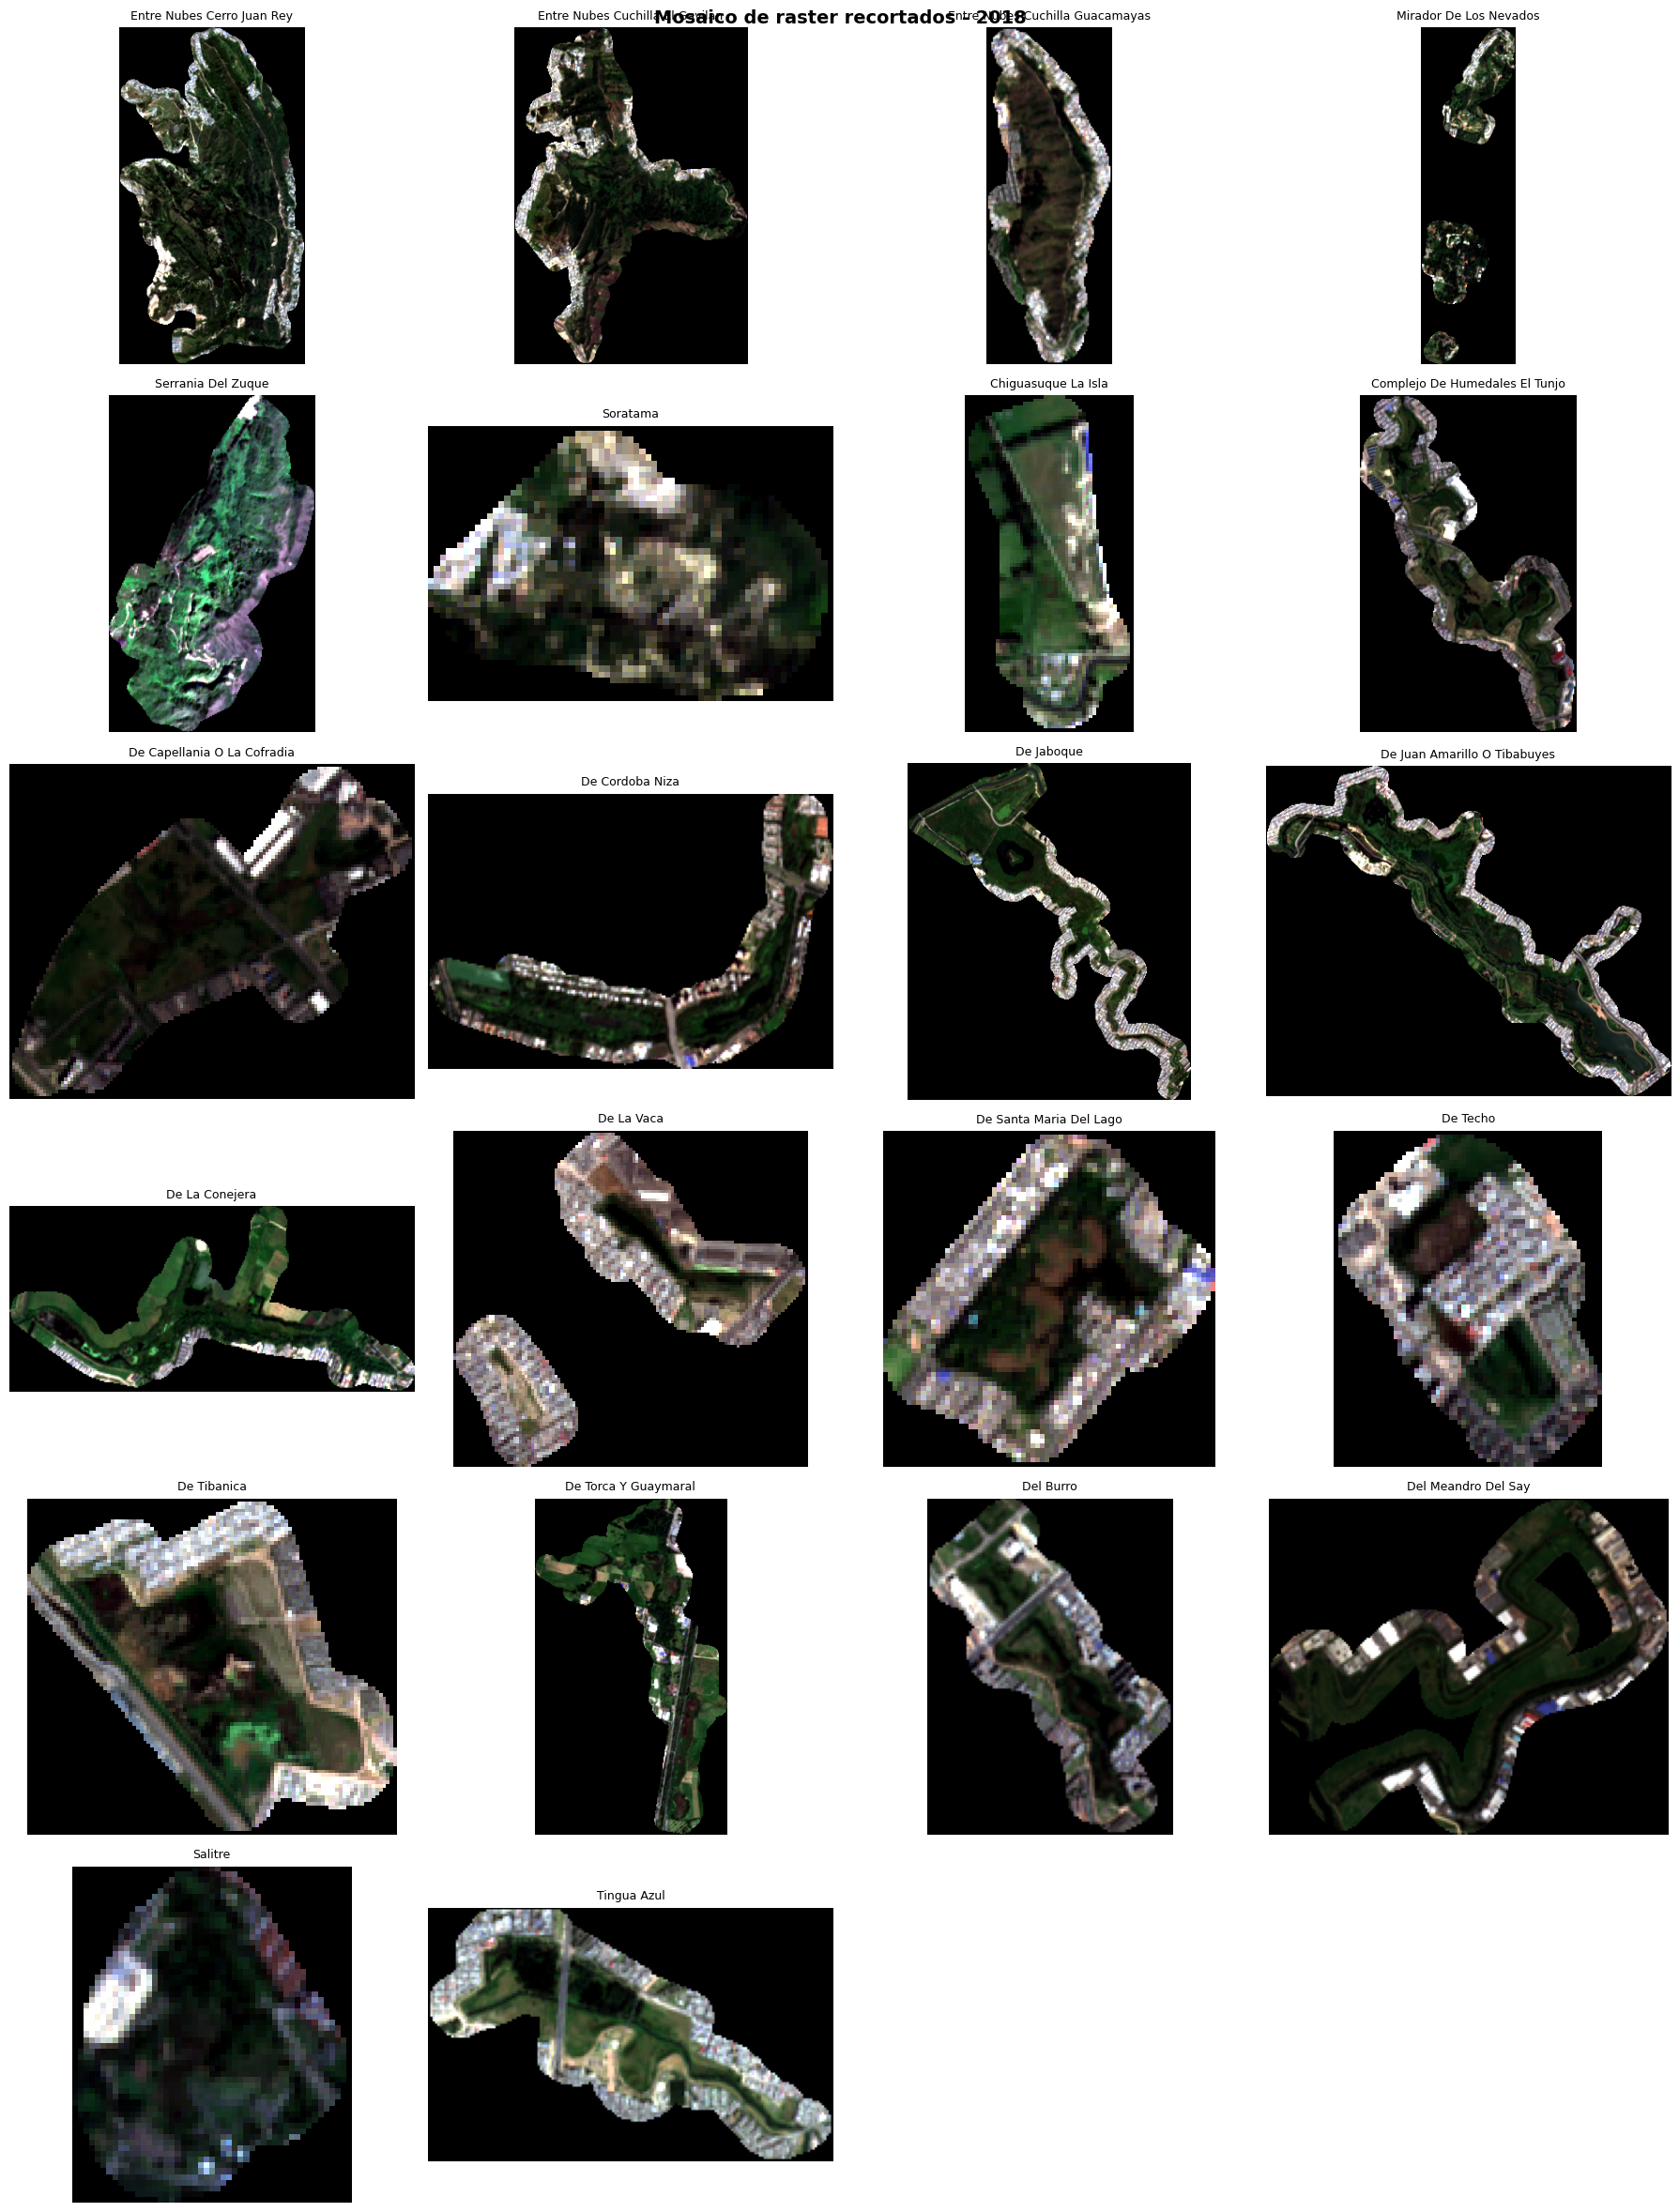

In [7]:
ruta_figura_mosaico = carpeta_figuras / f"mosaico_rasters_recortados_{year}.png"

visualizar_mosaico_rasters(
    rutas_raster=rutas_rasters,
    ruta_figura=ruta_figura_mosaico,
    cols=4,
    titulo=f"Mosaico de raster recortados - {year}"
)

## Definición de nombres de variables

Se define la lista de variables esperadas en el stack Sentinel-2:

- bandas espectrales;
- índices espectrales;
- texturas GLCM.

Estos nombres se usan en la matriz de correlación y en la selección de variables, siempre que coincidan con el número de bandas del raster.


In [8]:
feature_names = obtener_feature_names_clasificacion()
grupo_bandas, colores_grupo = obtener_grupos_bandas()

print("Número de variables definidas:")
print(len(feature_names))

feature_names

Número de variables definidas:
48


['B2',
 'B3',
 'B4',
 'B8',
 'B5',
 'B6',
 'B7',
 'B8A',
 'B11',
 'B12',
 'NDVI',
 'EVI',
 'SAVI',
 'MNDWI',
 'NDMI',
 'NDBI',
 'TEX_B2_contrast',
 'TEX_B2_diss',
 'TEX_B2_ent',
 'TEX_B2_asm',
 'TEX_B2_idm',
 'TEX_B2_corr',
 'TEX_B2_var',
 'TEX_B2_sent',
 'TEX_B3_contrast',
 'TEX_B3_diss',
 'TEX_B3_ent',
 'TEX_B3_asm',
 'TEX_B3_idm',
 'TEX_B3_corr',
 'TEX_B3_var',
 'TEX_B3_sent',
 'TEX_B4_contrast',
 'TEX_B4_diss',
 'TEX_B4_ent',
 'TEX_B4_asm',
 'TEX_B4_idm',
 'TEX_B4_corr',
 'TEX_B4_var',
 'TEX_B4_sent',
 'TEX_B8_contrast',
 'TEX_B8_diss',
 'TEX_B8_ent',
 'TEX_B8_asm',
 'TEX_B8_idm',
 'TEX_B8_corr',
 'TEX_B8_var',
 'TEX_B8_sent']

## Visualización de bandas del raster seleccionado

Se visualizan las bandas del raster seleccionado usando los nombres reales de variables cuando el número de bandas coincide con la lista esperada.


Figura guardada en:
C:\Users\AVDON\JupyterLab\ATENEA\humedales_bogota_ml\outputs\figures\clasificacion_coberturas\mosaico_bandas_pdem_entre_nubes_cuchilla_guacamayas_clip.png


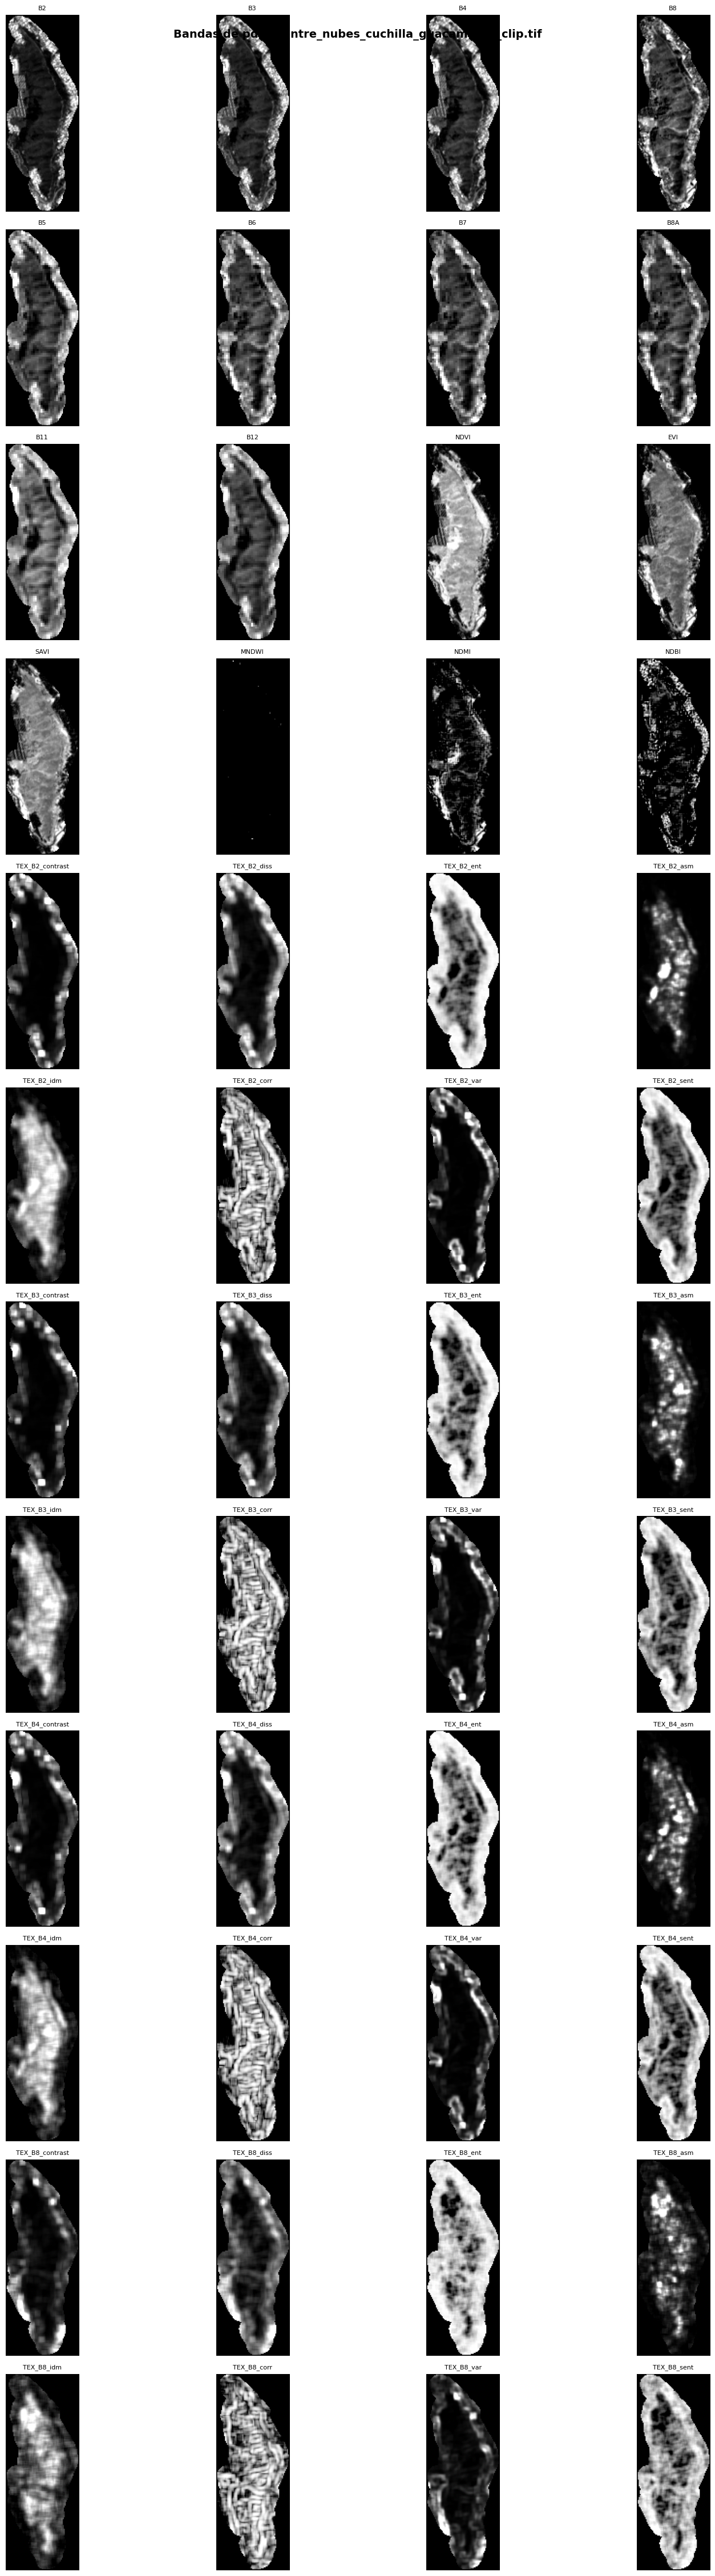

In [9]:
ruta_figura_bandas = carpeta_figuras / f"mosaico_bandas_{ruta_raster.stem}.png"

visualizar_mosaico_bandas(
    ruta_raster=ruta_raster,
    feature_names=feature_names,
    ruta_figura=ruta_figura_bandas,
    stretch=True,
    cols=4
)

## Análisis de correlación y selección de variables

Se calcula una matriz de correlación Pearson y Spearman a partir de una muestra de píxeles válidos del raster.

Luego se seleccionan variables usando un umbral de correlación absoluta. Las variables con alta correlación se eliminan para reducir redundancia espectral y textural.

Los nombres reales de las bandas se usan en esta etapa cuando coinciden con el número de bandas del raster.


In [22]:
# ============================================================
# PARÁMETROS DE CORRELACIÓN
# ============================================================

max_pixeles = 100_000
random_state = 42

threshold_pares = 0.90
threshold_seleccion = 0.925

nodata_val = -9999
excluir_fondo_cero = True

nombre_raster_reducido = f"S2_REDUCIDO_PEARSON_{year}"

ruta_raster_reducido = carpeta_reducidos / f"{nombre_raster_reducido}.tif"
ruta_bandas_json = carpeta_reducidos / f"bandas_pearson_{year}.json"

print("Máximo de píxeles para correlación:", max_pixeles)
print("Umbral para reporte de pares:", threshold_pares)
print("Umbral para selección de variables:", threshold_seleccion)

print("\nRaster reducido:")
print(ruta_raster_reducido)

print("\nJSON de variables seleccionadas:")
print(ruta_bandas_json)

Máximo de píxeles para correlación: 100000
Umbral para reporte de pares: 0.9
Umbral para selección de variables: 0.925

Raster reducido:
C:\Users\AVDON\JupyterLab\ATENEA\humedales_bogota_ml\data\interim\clasificacion_coberturas\reducidos\S2_REDUCIDO_PEARSON_2018.tif

JSON de variables seleccionadas:
C:\Users\AVDON\JupyterLab\ATENEA\humedales_bogota_ml\data\interim\clasificacion_coberturas\reducidos\bandas_pearson_2018.json


In [23]:
resultados_raster = pipeline_preparacion_raster(
    ruta_raster=ruta_raster,
    feature_names=feature_names,
    carpeta_tablas=carpeta_tablas,
    carpeta_figuras=carpeta_figuras,
    ruta_raster_reducido=ruta_raster_reducido,
    ruta_bandas_json=ruta_bandas_json,
    max_pixeles=max_pixeles,
    random_state=random_state,
    threshold_pares=threshold_pares,
    threshold_seleccion=threshold_seleccion,
    nodata_val=nodata_val,
    excluir_fondo_cero=excluir_fondo_cero
)

band_names = resultados_raster["band_names"]
corr_pearson = resultados_raster["corr_pearson"]
corr_spearman = resultados_raster["corr_spearman"]
pares_pearson = resultados_raster["pares_pearson"]
pares_spearman = resultados_raster["pares_spearman"]
variables_finales = resultados_raster["variables_finales"]
variables_eliminadas = resultados_raster["variables_eliminadas"]
df_variables = resultados_raster["df_variables"]

print("Preparación de raster completada.")

Píxeles totales: 15504
Píxeles válidos usados para correlación: 9854
Píxeles muestreados: 9854
Tabla guardada en:
C:\Users\AVDON\JupyterLab\ATENEA\humedales_bogota_ml\outputs\tables\clasificacion_coberturas\pares_correlacion_pearson.csv
Tabla guardada en:
C:\Users\AVDON\JupyterLab\ATENEA\humedales_bogota_ml\outputs\tables\clasificacion_coberturas\pares_correlacion_spearman.csv
Tabla guardada en:
C:\Users\AVDON\JupyterLab\ATENEA\humedales_bogota_ml\outputs\tables\clasificacion_coberturas\variables_seleccionadas_pearson.csv
Raster reducido guardado en:
C:\Users\AVDON\JupyterLab\ATENEA\humedales_bogota_ml\data\interim\clasificacion_coberturas\reducidos\S2_REDUCIDO_PEARSON_2018.tif
Archivo JSON guardado en:
C:\Users\AVDON\JupyterLab\ATENEA\humedales_bogota_ml\data\interim\clasificacion_coberturas\reducidos\bandas_pearson_2018.json
Preparación de raster completada.


In [24]:
print("Dimensiones de la muestra usada para correlación:")
print(resultados_raster["df_muestra"].shape)

print("\nResumen estadístico de la muestra:")
display(resultados_raster["df_muestra"].describe().T[["min", "mean", "std", "max"]].head(20))

Dimensiones de la muestra usada para correlación:
(9854, 48)

Resumen estadístico de la muestra:


,min,mean,std,max
B2,0.000100,0.047053,0.048062,0.394000
B3,0.005000,0.073360,0.047716,0.437600
B4,0.008700,0.078470,0.052548,0.434000
B8,0.069500,0.192588,0.053528,0.496000
B5,0.034800,0.110582,0.042234,0.316700
B6,0.083900,0.170071,0.041494,0.361900
B7,0.095300,0.187648,0.047018,0.451100
B8A,0.101000,0.202367,0.048724,0.479900
B11,0.078900,0.183366,0.042662,0.378700
B12,0.039500,0.138170,0.053083,0.419500


## Pares altamente correlacionados

Se revisan los principales pares de variables con correlación alta según Pearson y Spearman.


In [25]:
print("Top pares Pearson:")
display(pares_pearson.head(30))

print("\nTop pares Spearman:")
display(pares_spearman.head(30))

Top pares Pearson:


,band1,band2,r
0,NDMI,NDBI,-1.000000
1,EVI,SAVI,0.986639
2,TEX_B3_diss,TEX_B4_diss,0.982754
3,TEX_B2_ent,TEX_B2_sent,0.981760
4,B3,B4,0.979636
5,B7,B8A,0.974754
6,TEX_B2_diss,TEX_B3_diss,0.973646
7,TEX_B2_ent,TEX_B2_idm,-0.972617
8,B2,B3,0.971370
9,TEX_B3_ent,TEX_B3_sent,0.971028



Top pares Spearman:


,band1,band2,r
0,NDMI,NDBI,-1.000000
1,TEX_B8_ent,TEX_B8_asm,-0.997626
2,TEX_B3_ent,TEX_B3_asm,-0.996673
3,TEX_B4_ent,TEX_B4_asm,-0.995966
4,TEX_B8_contrast,TEX_B8_diss,0.995084
5,TEX_B3_contrast,TEX_B3_diss,0.994351
6,TEX_B2_ent,TEX_B2_asm,-0.993877
7,TEX_B2_contrast,TEX_B2_diss,0.993729
8,TEX_B4_contrast,TEX_B4_diss,0.992921
9,EVI,SAVI,0.985907


## Matriz de correlación Pearson

Se visualiza y guarda la matriz de correlación Pearson del raster seleccionado.


Figura guardada en:
C:\Users\AVDON\JupyterLab\ATENEA\humedales_bogota_ml\outputs\figures\clasificacion_coberturas\matriz_correlacion_pearson_pdem_entre_nubes_cuchilla_guacamayas_clip.png


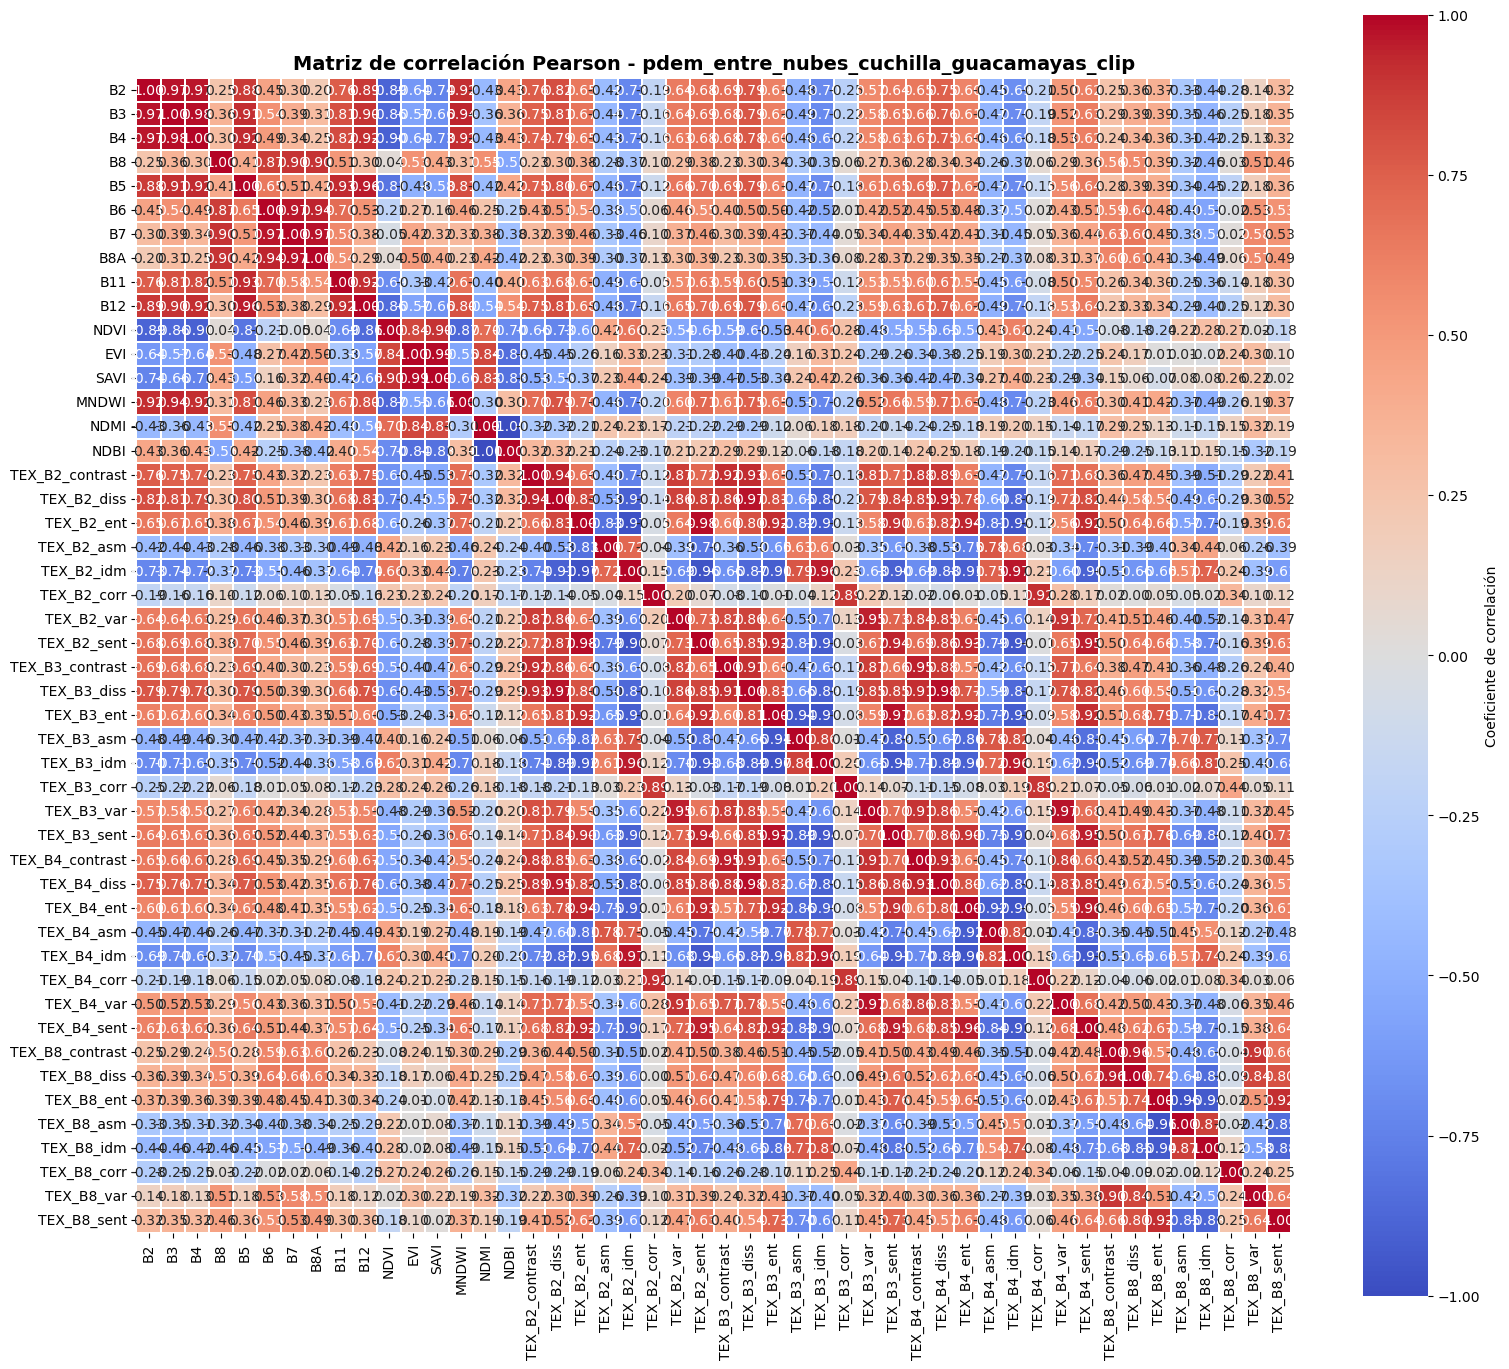

In [26]:
ruta_figura_corr = carpeta_figuras / f"matriz_correlacion_pearson_{ruta_raster.stem}.png"

graficar_matriz_correlacion(
    matriz_corr=corr_pearson,
    titulo=f"Matriz de correlación Pearson - {ruta_raster.stem}",
    ruta_figura=ruta_figura_corr,
    cmap="coolwarm",
    annot=True,
    figsize=(16, 14)
)

## Variables seleccionadas

Se presenta la lista de variables eliminadas por alta correlación y las variables finales que componen el raster reducido.


In [27]:
print("Variables eliminadas:")
for variable in variables_eliminadas:
    print("-", variable)

print("\nVariables seleccionadas:")
for variable in variables_finales:
    print("-", variable)

print("\nTotal inicial:", len(band_names))
print("Total final:", len(variables_finales))
print("Variables eliminadas:", len(variables_eliminadas))

display(df_variables)

Variables eliminadas:
- B3
- B4
- B7
- B8A
- B11
- B12
- SAVI
- MNDWI
- NDBI
- TEX_B2_diss
- TEX_B2_idm
- TEX_B2_sent
- TEX_B3_diss
- TEX_B3_asm
- TEX_B3_idm
- TEX_B3_var
- TEX_B3_sent
- TEX_B4_contrast
- TEX_B4_diss
- TEX_B4_ent
- TEX_B4_idm
- TEX_B4_var
- TEX_B4_sent
- TEX_B8_diss
- TEX_B8_asm
- TEX_B8_idm

Variables seleccionadas:
- B2
- B8
- B5
- B6
- NDVI
- EVI
- NDMI
- TEX_B2_contrast
- TEX_B2_ent
- TEX_B2_asm
- TEX_B2_corr
- TEX_B2_var
- TEX_B3_contrast
- TEX_B3_ent
- TEX_B3_corr
- TEX_B4_asm
- TEX_B4_corr
- TEX_B8_contrast
- TEX_B8_ent
- TEX_B8_corr
- TEX_B8_var
- TEX_B8_sent

Total inicial: 48
Total final: 22
Variables eliminadas: 26


,variable,seleccionada,eliminada
0,B2,True,False
1,B3,False,True
2,B4,False,True
3,B8,True,False
4,B5,True,False
5,B6,True,False
6,B7,False,True
7,B8A,False,True
8,B11,False,True
9,B12,False,True


## Visualización del raster reducido

Se visualizan las bandas del raster reducido generado a partir de las variables seleccionadas.


Figura guardada en:
C:\Users\AVDON\JupyterLab\ATENEA\humedales_bogota_ml\outputs\figures\clasificacion_coberturas\mosaico_bandas_S2_REDUCIDO_PEARSON_2018.png


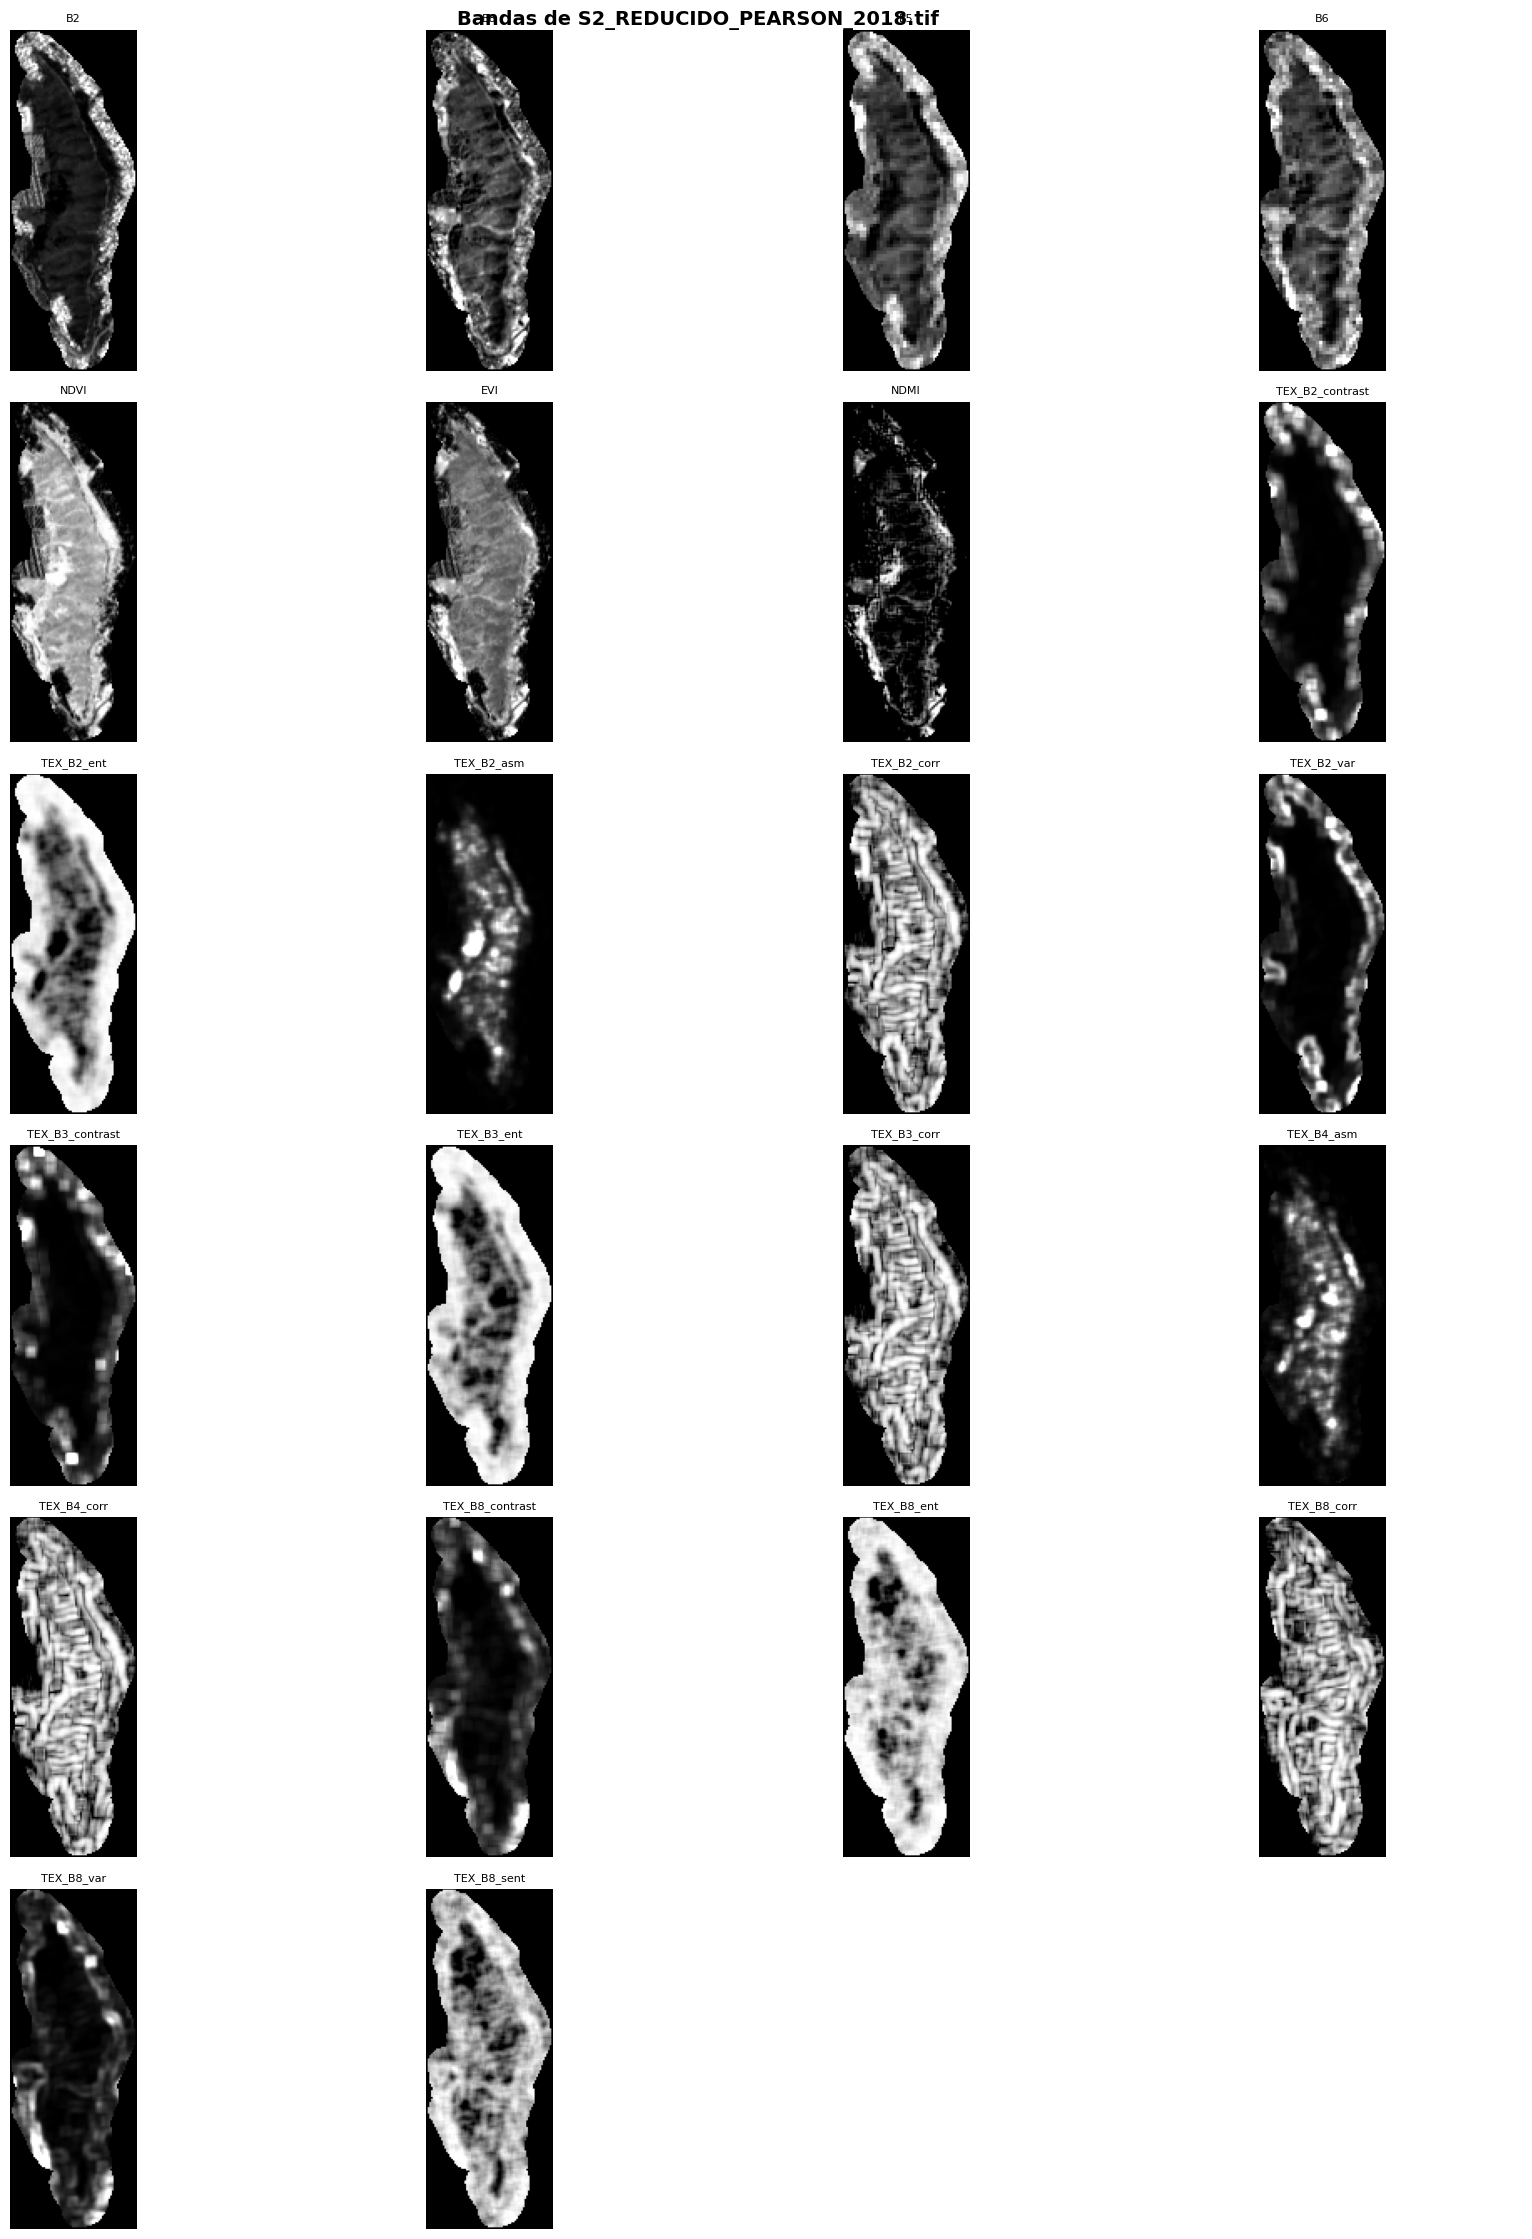

In [28]:
ruta_figura_reducido = carpeta_figuras / f"mosaico_bandas_{nombre_raster_reducido}.png"

visualizar_mosaico_bandas(
    ruta_raster=ruta_raster_reducido,
    feature_names=variables_finales,
    ruta_figura=ruta_figura_reducido,
    stretch=True,
    cols=4
)

## Preprocesamiento del raster reducido

Se prepara el raster reducido como una matriz de entrada para modelos de machine learning.

El raster se normaliza banda por banda y se reorganiza como una matriz:

`píxeles × variables`

Este objeto será utilizado en etapas posteriores para extracción de muestras e inferencia espacial.


In [29]:
info_raster = preprocesar_raster(
    ruta_raster=ruta_raster_reducido,
    usar_scaler=True
)

print("Número de bandas:", info_raster["n_bandas"])
print("Filas:", info_raster["filas"])
print("Columnas:", info_raster["columnas"])
print("Shape X:", info_raster["X"].shape)

Número de bandas: 22
Filas: 204
Columnas: 76
Shape X: (15504, 22)


## Producto de esta etapa

Al finalizar este notebook se generan:

- raster reducido por selección de variables;
- archivo JSON con las variables seleccionadas;
- tablas de pares altamente correlacionados;
- tabla de variables seleccionadas;
- figuras de visualización del raster y matriz de correlación.

El raster reducido se guarda en:

`data/interim/clasificacion_coberturas/REDUCIDOS/`

## Siguiente etapa del flujo

Una vez preparado el raster reducido, el siguiente paso consiste en cargar los puntos de entrenamiento, extraer los valores raster asociados y generar el split estratificado para clasificación.

Esta fase se documenta en:

`04_preparacion_muestras.ipynb`
